# ОДНОРОДНЫЕ ФИЛЬТРЫ или ФИЛЬТР СКОЛЬЗЯЩЕГО СРЕДНЕГО

Однородные фильтры превосходят все остальные виды цифровых фильтров при обработке информации, представленной во временной области. В то же время эти фильтры оказываются малоэффективны при обработке информации в частотной област Следует помнить, что фильтра, лучшего, чем однородный, с точки зрения подавления шума не существует.и.

Однородные фильтры часто называют фильтрами скользящего среднего:

$$
y[i] = \frac{1}{M} \sum_{j=0}^{M-1} x[i + j]
$$

$$
y[80] = \frac{x[80] + x[81] + x[82] + x[83] + x[84]}{5}
$$

$$
y[80] = \frac{x[78] + x[79] + x[80] + x[81] + x[82]}{5}
$$

При симметричном усреднении необходимо, чтобы $ M $ был


Какие же преимущества характерны для рассмотренных выше модификацийоднородных фильтров? Основных преимуществ — три. Во-первых, модифициро-ванные однородные фильтры позволяют достичь большего подавления в зоне не-прозрачности, чем обычные однородные фильтры. Во-вторых, их импульсная ха-рактеристика на краях плавно сходится к нулю. Как вы помните, каждый отсчётвыходного сигнала определяется взвешенной суммой группы входных отсчётов.Поэтому сходимость к нулю импульсной характеристики означает, что отсчёты,близкие к центру такой группы, оказывают более сильное влияние на формиро-вание выходного отсчёта. В-третьих, переходные процессы модифицированныхфильтров оказываются более плавными и не имеют резких изгибов. Последниедва преимущества менее важны, хотя, надо заметить, существует ряд приложе-ний, в которых они оказываются очень полезными.о нечётным числом.

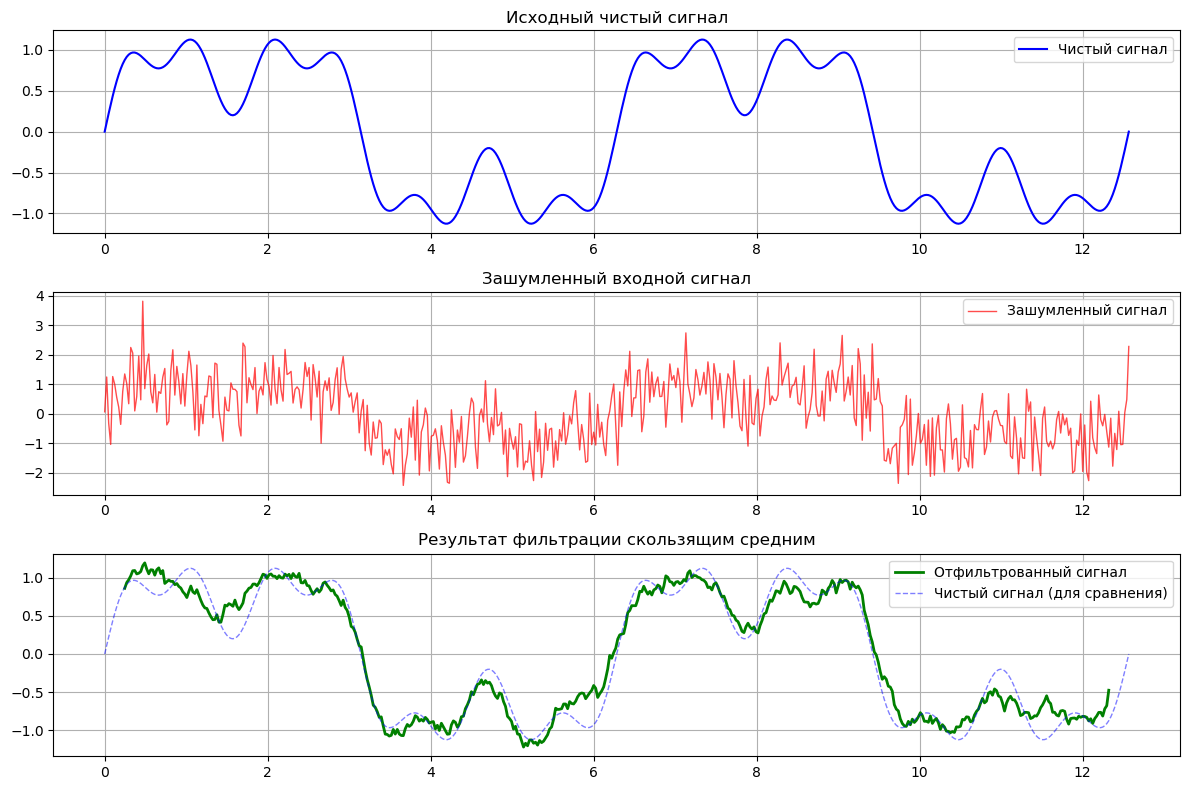

Обработано отсчётов: 512
Порядок фильтра: 21
Размер окна усреднения: 21 точек
Краевые эффекты: 10 точек с каждой стороны не обрабатываются


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ОДНОРОДНЫЙ НЕРЕКУРСИВНЫЙ ФИЛЬТР (ФИЛЬТР СКОЛЬЗЯЩЕГО СРЕДНЕГО)
# Данная программа предназначена для обработки 512 отсчётов
# входного сигнала однородным фильтром 21-го порядка (для 512 отсчётов)

def generate_noisy_signal(n_samples=512):
    """
    Генерация зашумленного тестового сигнала
    """
    t = np.linspace(0, 4*np.pi, n_samples)
    
    # Полезный сигнал - комбинация синусов разных частот
    signal = (np.sin(t) + 0.5 * np.sin(3*t) + 0.3 * np.sin(7*t))
    
    # Добавление шума
    noise = 0.8 * np.random.normal(0, 1, n_samples)
    noisy_signal = signal + noise
    
    return noisy_signal, signal, t


# Цикл 1: for i in range(HALF_ORDER, N - HALF_ORDER)
# i - это центральная точка окна фильтра
# Начало: HALF_ORDER = 10 - мы не можем взять окно с центром в точке 0-9, потому что не хватит точек слева
# Конец: N - HALF_ORDER = 512 - 10 = 502 - мы не можем взять окно с центром в точке 502-511, потому что не хватит точек справа
# Диапазон i: от 10 до 501 (включительно)
# Минимальный i = 10: окно охватывает точки X[0] до X[20]
# Максимальный i = 501: окно охватывает точки X[491] до X[511]
# Результат: обрабатываются точки Y[10] до Y[501] (всего 492 точки)

# Цикл 2: for j in range(-HALF_ORDER, HALF_ORDER + 1)
# Объяснение:
# j - это смещение относительно центральной точки i
# Начало: -HALF_ORDER = -10 - берем 10 точек слева от центра
# Конец: HALF_ORDER + 1 = 10 + 1 = 11 - берем 10 точек справа от центра + сам центр
# Диапазон j: от -10 до +10 (включительно)
# Всего 21 значение: [-10, -9, -8, ..., -1, 0, +1, ..., +8, +9, +10]


# Параметры
N = 512  # количество отсчётов
FILTER_ORDER = 21  # порядок фильтра (нечётное число)
HALF_ORDER = FILTER_ORDER // 2

# X – массив отсчётов входного сигнала
# Y – массив отсчётов выходного сигнала
X = [0] * N
Y = [0] * N

# Генерация тестового сигнала
X_noisy, X_clean, time = generate_noisy_signal(N)
X = X_noisy.tolist()  # преобразуем в список для совместимости
# Применение фильтра скользящего среднего
for i in range(HALF_ORDER, N - HALF_ORDER):
    Y[i] = 0  # Предварительное обнуление
    # Цикл для вычисления очередного отсчёта
    for j in range(-HALF_ORDER, HALF_ORDER + 1):
        Y[i] = Y[i] + X[i + j]
    Y[i] = Y[i] / FILTER_ORDER  # Завершение усреднения

# Визуализация результатов
plt.figure(figsize=(12, 8))

# Исходный чистый сигнал
plt.subplot(3, 1, 1)
plt.plot(time, X_clean, 'b-', linewidth=1.5, label='Чистый сигнал')
plt.title('Исходный чистый сигнал')
plt.grid(True)
plt.legend()

# Зашумленный сигнал
plt.subplot(3, 1, 2)
plt.plot(time, X, 'r-', linewidth=1, alpha=0.7, label='Зашумленный сигнал')
plt.title('Зашумленный входной сигнал')
plt.grid(True)
plt.legend()

# Отфильтрованный сигнал
plt.subplot(3, 1, 3)
plt.plot(time[HALF_ORDER:N-HALF_ORDER], Y[HALF_ORDER:N-HALF_ORDER], 
         'g-', linewidth=2, label='Отфильтрованный сигнал')
plt.plot(time, X_clean, 'b--', linewidth=1, alpha=0.5, label='Чистый сигнал (для сравнения)')
plt.title('Результат фильтрации скользящим средним')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# Вывод статистики
print(f"Обработано отсчётов: {N}")
print(f"Порядок фильтра: {FILTER_ORDER}")
print(f"Размер окна усреднения: {FILTER_ORDER} точек")
print(f"Краевые эффекты: {HALF_ORDER} точек с каждой стороны не обрабатываются")

# ОДНОРОДНЫЕ ФИЛЬТРЫ

Однородные фильтры превосходят все остальные виды цифровых фильтров при обработке информации, представленной во временной области. В то же время эти фильтры оказываются малоэффективны при обработке информации в частотной области.

Однородные фильтры часто называют фильтрами скользящего среднего:

$$
y[i] = \frac{1}{M} \sum_{j=0}^{M-1} x[i + j]
$$

$$
y[80] = \frac{x[80] + x[81] + x[82] + x[83] + x[84]}{5}
$$

$$
y[80] = \frac{x[78] + x[79] + x[80] + x[81] + x[82]}{5}
$$

При симметричном усреднении необходимо, чтобы $ M $ было нечётным числом.

---

## Однородные рекурсивные фильтры

В частности, импульсная характеристика однородных фильтров имеет вид прямоугольного импульса, т. е. это фильтры с конечной импульсной характеристикой, или КИХ-фильтры, в то время как рекурсивные фильтры образуют класс БИХ-фильтров, а их импульсная характеристика имеет бесконечную длину и представляется набором синусоид и экспонент.

Пусть сигнал $ x[\cdot] $ поступает на вход однородного нерекурсивного фильтра седьмого порядка, а $ y[\cdot] $ — реакция этого фильтра. Тогда отсчёты $ y[50] $ и $ y[51] $ выражаются соотношениями:

$$
y[50] = x[47] + x[48] + x[49] + x[50] + x[51] + x[52] + x[53]
$$

и

$$
y[51] = x[48] + x[49] + x[50] + x[51] + x[52] + x[53] + x[54].
$$

Эти выражения во многом повторяют друг друга, поскольку отсчёты $ 48...53 $ используются для вычисления и $ y[50] $, и $ y[51] $. Если $ y[50] $ уже найден, то существует более эффективный способ вычислить $ y[51] $:

$$
y[51] = y[50] + x[54] - x[47].
$$

Если найдено значение $ y[50] $, то $ y[51] $ проще всего выразить через него. То же самое относится и к последующим отсчётам выходной последовательности. Если найден один отсчёт выходного сигнала $ y[\cdot] $, каждый последующий может быть найден в результате одной операции сложения и одной операции вычитания:

$$
y[i] = y[i-1] + x[i + p] - x[i - q], \tag{15.3}
$$

где

$$
p = \frac{M - 1}{2}, \quad q = p + 1.
$$

**Однородный рекурсивный фильтр.** Здесь $ x[\cdot] $ — входной сигнал, $ y[\cdot] $ — выходной сигнал, $ M $ — число (нечётное) усредняемых отсчётов. Перед началом использования этой формулы необходимо вычислить первый отсчёт выходной последовательности простым суммированием.

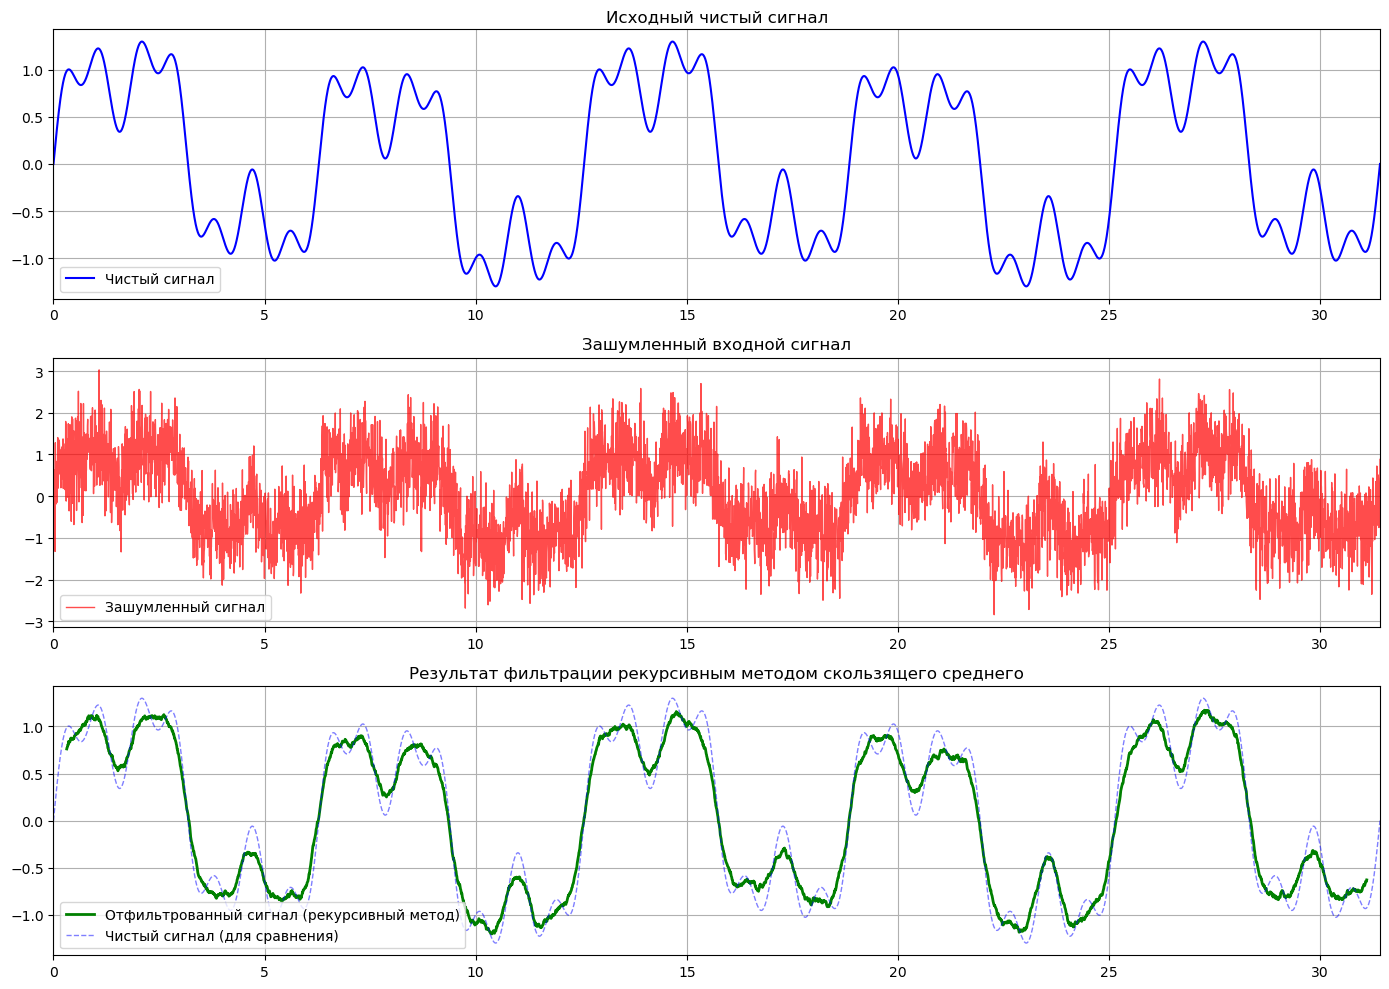

Сравнение методов фильтрации:
Обработано отсчётов: 5000
Порядок фильтра: 101
Размер окна усреднения: 101 точек
Краевые эффекты: 50 точек с каждой стороны не обрабатываются

Проверка корректности для точки 1000:
Рекурсивный метод: 0.031811
Нерекурсивный метод: 0.031811
Разница: 3.68e-16

Эффективность рекурсивного метода:
Количество операций сложения/вычитания на точку: 2
В нерекурсивном методе: 101 операций на точку
Ускорение: примерно в 50.5 раз


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def generate_test_signal(n_samples=5000):
    """
    Генерация тестового зашумленного сигнала
    """
    t = np.linspace(0, 10*np.pi, n_samples)
    
    # Полезный сигнал - комбинация синусов разных частот
    signal = (np.sin(t) + 0.5 * np.sin(3*t) + 0.3 * np.sin(7*t) + 
              0.2 * np.sin(0.5*t))
    
    # Добавление шума
    noise = 0.6 * np.random.normal(0, 1, n_samples)
    noisy_signal = signal + noise
    
    return noisy_signal, signal, t

# ОДНОРОДНЫЙ РЕКУРСИВНЫЙ ФИЛЬТР (ФИЛЬТР СКОЛЬЗЯЩЕГО СРЕДНЕГО)
# Данная программа предназначена для обработки 5000 отсчётов
# входного сигнала однородным фильтром 101-го порядка.
# Для устранения дрейфа накопление происходит с повышенной точностью.

# Параметры
N = 5000  # количество отсчётов
FILTER_ORDER = 101  # порядок фильтра
HALF_ORDER = FILTER_ORDER // 2  # = 50

# X – массив отсчётов входного сигнала
# Y – массив отсчётов выходного сигнала
X = np.zeros(N)
Y = np.zeros(N)

# Переменная для накопления с повышенной точностью
ACC = 0.0

# Генерация тестового сигнала
X_noisy, X_clean, time = generate_test_signal(N)
X = X_noisy  # используем зашумленный сигнал как вход

# Вычисление Y[50] усреднением отсчётов X[0]…X[100]
ACC = 0.0
for i in range(0, FILTER_ORDER):  # 0 до 100 включительно
    ACC += X[i]
Y[HALF_ORDER] = ACC / FILTER_ORDER  # Y[50]

# Однородный рекурсивный фильтр (выражение 15.3)
for i in range(HALF_ORDER + 1, N - HALF_ORDER):  # от 51 до 4949
    # Обновляем сумму: добавляем новый отсчёт и вычитаем старый
    ACC = ACC + X[i + HALF_ORDER] - X[i - HALF_ORDER - 1]
    Y[i] = ACC / FILTER_ORDER

# Визуализация результатов
plt.figure(figsize=(14, 10))

# Исходный чистый сигнал
plt.subplot(3, 1, 1)
plt.plot(time, X_clean, 'b-', linewidth=1.5, label='Чистый сигнал')
plt.title('Исходный чистый сигнал')
plt.grid(True)
plt.legend()
plt.xlim(0, time[-1])

# Зашумленный сигнал
plt.subplot(3, 1, 2)
plt.plot(time, X, 'r-', linewidth=1, alpha=0.7, label='Зашумленный сигнал')
plt.title('Зашумленный входной сигнал')
plt.grid(True)
plt.legend()
plt.xlim(0, time[-1])

# Отфильтрованный сигнал
plt.subplot(3, 1, 3)
plt.plot(time[HALF_ORDER:N-HALF_ORDER], Y[HALF_ORDER:N-HALF_ORDER], 
         'g-', linewidth=2, label='Отфильтрованный сигнал (рекурсивный метод)')
plt.plot(time, X_clean, 'b--', linewidth=1, alpha=0.5, label='Чистый сигнал (для сравнения)')
plt.title('Результат фильтрации рекурсивным методом скользящего среднего')
plt.grid(True)
plt.legend()
plt.xlim(0, time[-1])

plt.tight_layout()
plt.show()

# Сравнение с нерекурсивным методом для проверки
print("Сравнение методов фильтрации:")
print(f"Обработано отсчётов: {N}")
print(f"Порядок фильтра: {FILTER_ORDER}")
print(f"Размер окна усреднения: {FILTER_ORDER} точек")
print(f"Краевые эффекты: {HALF_ORDER} точек с каждой стороны не обрабатываются")

# Проверка: вычисление одного значения нерекурсивным методом для сравнения
test_index = 1000
non_recursive_sum = 0
for j in range(-HALF_ORDER, HALF_ORDER + 1):
    non_recursive_sum += X[test_index + j]
non_recursive_value = non_recursive_sum / FILTER_ORDER

print(f"\nПроверка корректности для точки {test_index}:")
print(f"Рекурсивный метод: {Y[test_index]:.6f}")
print(f"Нерекурсивный метод: {non_recursive_value:.6f}")
print(f"Разница: {abs(Y[test_index] - non_recursive_value):.2e}")

# Анализ эффективности
print(f"\nЭффективность рекурсивного метода:")
print(f"Количество операций сложения/вычитания на точку: 2")
print(f"В нерекурсивном методе: {FILTER_ORDER} операций на точку")
print(f"Ускорение: примерно в {FILTER_ORDER/2:.1f} раз")